# 01. Naive Descriptive Statistics: The Mayor's Report

Welcome to the Smart City Analytics Team. 

**The Situation:** The Mayor has just proposed a controversial new policy: **"Revoke driver's licenses for anyone over 65 years old."**

The Mayor's reasoning? *"My data analysts prepared an extensive 6-graph descriptive report. The data is irrefutable: older people are a danger to the city!"*

Before we look at the Mayor's graphs, let's understand the data we are working with.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv('smart_city_road_safety_synthetic_5000.csv')
df.head()

,Driver_Age,Vision_Quality,Driving_Speed,Weather,Accident,Severe_Hospitalization
0,43.1,85.2,68.5,Clear,0,0
1,81.7,22.0,58.0,Snow,1,1
2,67.0,73.0,50.5,Clear,0,1
3,58.1,91.3,62.5,Snow,0,0
4,28.5,100.0,73.8,Clear,1,0


## 📖 Data Dictionary
Our dataset contains 5,000 traffic records from the Smart City database. Here are the variables we have collected:

1. **`Driver_Age`**: The exact age of the driver (Continuous).
2. **`Vision_Quality`**: A score from 0 to 100 measuring the driver's visual acuity (100 = perfect 20/20 vision).
3. **`Driving_Speed`**: The average speed of the vehicle in km/h right before the incident/measurement.
4. **`Weather`**: Categorical variable indicating the road conditions (`Clear`, `Rain`, or `Snow`).
5. **`Accident`**: Binary outcome. `1` if the driver was involved in a car crash, `0` if they drove safely.
6. **`Severe_Hospitalization`**: Binary outcome. `1` if the driver ended up in the emergency room with severe injuries, `0` otherwise.

Let's look at the basic descriptive statistics of our numerical variables.

In [2]:
display(df.describe().round(2))

,Driver_Age,Vision_Quality,Driving_Speed,Accident,Severe_Hospitalization
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,51.29,80.02,66.72,0.29,0.29
std,19.41,18.77,12.67,0.46,0.45
min,18.00,13.30,30.00,0.00,0.00
25%,34.30,71.68,58.00,0.00,0.00
50%,51.50,85.50,66.80,0.00,0.00
75%,68.10,94.40,75.30,1.00,1.00
max,85.00,100.00,112.70,1.00,1.00


As we can see, we have drivers ranging from 18 to 85 years old. The overall accident rate in the city is around 13% (`Accident` mean). 

Now that we know the variables, let's look at the 6-graph report the Mayor used to justify banning the elderly.

---
## Graph 1: The Raw Accident Rate (Bar Plot)
First, the Mayor's team grouped drivers into generational buckets to see who crashes the most.

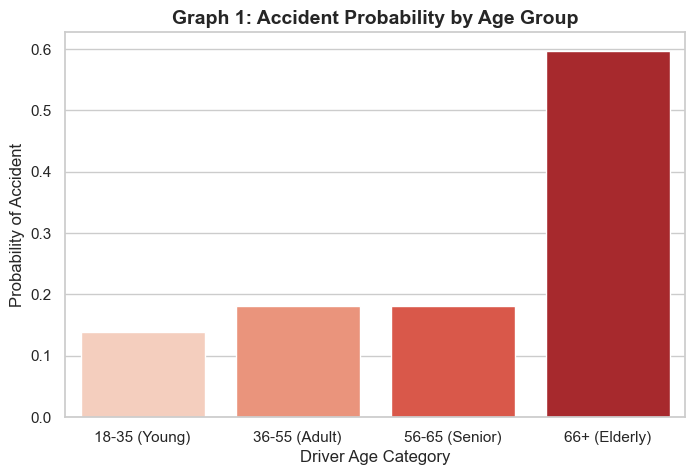

In [3]:
bins = [18, 35, 55, 65, 100] # Adjusted to perfectly align with the Mayor's 65+ ban
labels = ['18-35 (Young)', '36-55 (Adult)', '56-65 (Senior)', '66+ (Elderly)']
df['Age_Group'] = pd.cut(df['Driver_Age'], bins=bins, labels=labels, right=False)

accident_rates = df.groupby('Age_Group')['Accident'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=accident_rates, x='Age_Group', y='Accident', palette='Reds')
plt.title("Graph 1: Accident Probability by Age Group", fontsize=14, fontweight='bold')
plt.ylabel("Probability of Accident")
plt.xlabel("Driver Age Category")
plt.show()

**Mayor's Note:** "Look at the red bar on the right. The 66+ group has the highest accident rate in the city."

---
## Graph 2: The Continuous Risk (Line Plot)
Grouping into buckets can sometimes hide the truth. The Mayor's team plotted the rolling average of accident risk across every exact age.

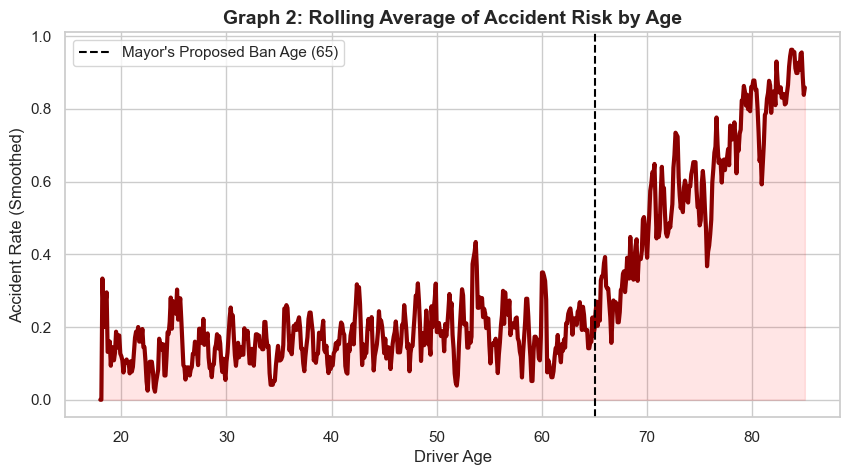

In [4]:
# Calculate rolling average of accidents by age
age_trend = df.groupby('Driver_Age')['Accident'].mean().rolling(window=5, min_periods=1).mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_trend, x='Driver_Age', y='Accident', color='darkred', linewidth=3)
plt.fill_between(age_trend['Driver_Age'], age_trend['Accident'], color='red', alpha=0.1)
plt.axvline(x=65, color='black', linestyle='--', label='Mayor\'s Proposed Ban Age (65)')
plt.title("Graph 2: Rolling Average of Accident Risk by Age", fontsize=14, fontweight='bold')
plt.ylabel("Accident Rate (Smoothed)")
plt.xlabel("Driver Age")
plt.legend()
plt.show()

**Mayor's Note:** "The risk skyrockets precisely after age 65. The line goes almost straight up!"

---
## Graph 3: The Profile of a Crashed Driver (KDE Density Plot)
If we only look at people who *did* have an accident, what does their age distribution look like compared to safe drivers?

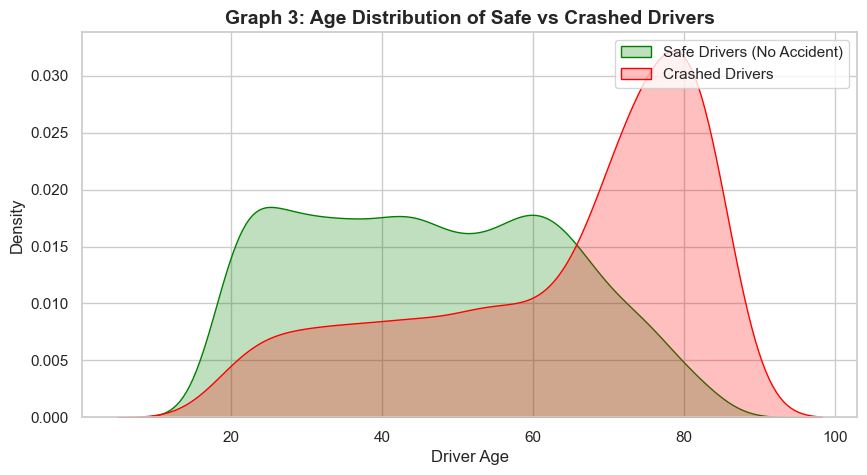

In [5]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['Accident']==0], x='Driver_Age', label='Safe Drivers (No Accident)', fill=True, color='green')
sns.kdeplot(data=df[df['Accident']==1], x='Driver_Age', label='Crashed Drivers', fill=True, color='red')
plt.title("Graph 3: Age Distribution of Safe vs Crashed Drivers", fontsize=14, fontweight='bold')
plt.xlabel("Driver Age")
plt.ylabel("Density")
plt.legend()
plt.show()

**Mayor's Note:** "The green curve (safe drivers) is spread evenly. But the red curve (crashed drivers) bulges heavily to the right. The accident database is crowded with old people!"

---
## Graph 4: Hospitalization Burden (Donut Chart)
Accidents are bad, but severe hospitalizations bankrupt the city. Do older drivers consume the city's hospital resources?

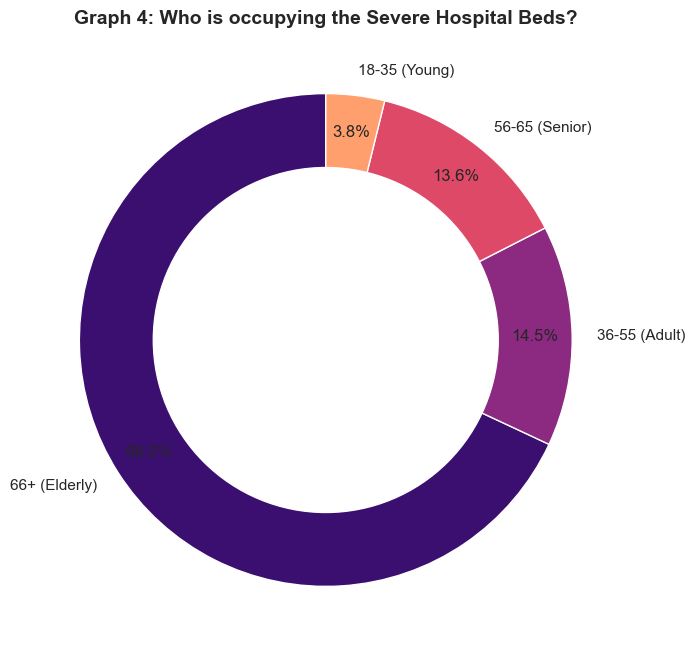

In [6]:
hospital_cases = df[df['Severe_Hospitalization'] == 1]['Age_Group'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(hospital_cases, labels=hospital_cases.index, autopct='%1.1f%%', startangle=90, 
        colors=sns.color_palette('magma', len(hospital_cases)), pctdistance=0.85)
# Draw circle to make it a donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Graph 4: Who is occupying the Severe Hospital Beds?", fontsize=14, fontweight='bold')
plt.show()

**Mayor's Note:** "The Elderly make up a massive chunk of our severe hospitalizations. They are a burden on the healthcare system!"

---
## Graph 5: The Hospitalization Rate by Age (Violin Plot)
Let's look at the distribution of age across the two hospital outcomes.

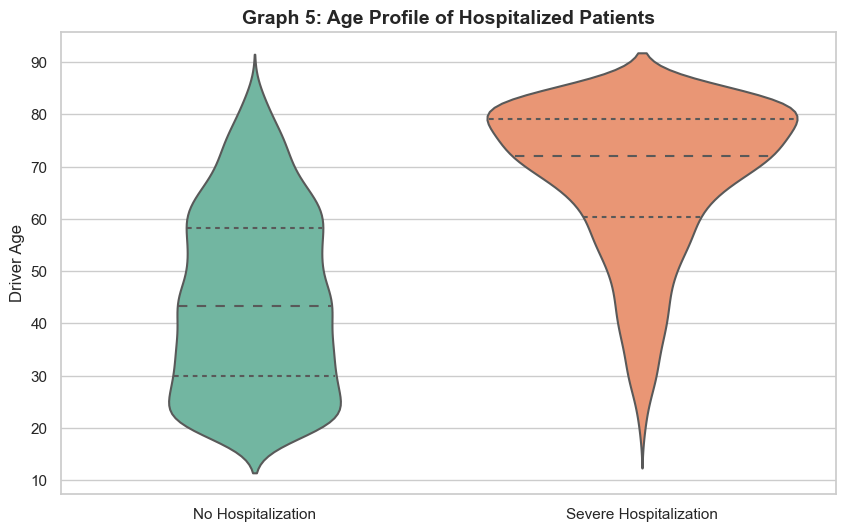

In [7]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Severe_Hospitalization', y='Driver_Age', palette='Set2', inner='quartile')
plt.xticks([0, 1], ['No Hospitalization', 'Severe Hospitalization'])
plt.title("Graph 5: Age Profile of Hospitalized Patients", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Driver Age")
plt.show()

**Mayor's Note:** "The violin for 'Severe Hospitalization' is heavily concentrated at the top (older ages). Young people rarely end up in the hospital."

---
## Graph 6: Weather makes it worse! (Heatmap)
Does bad weather affect them more? Let's cross-tabulate.

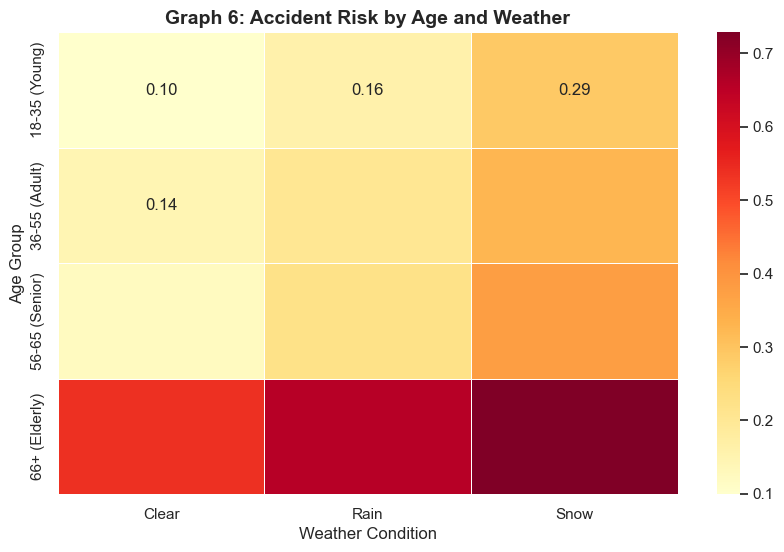

In [8]:
pivot_weather = df.pivot_table(values='Accident', index='Age_Group', columns='Weather', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_weather, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=.5)
plt.title("Graph 6: Accident Risk by Age and Weather", fontsize=14, fontweight='bold')
plt.ylabel("Age Group")
plt.xlabel("Weather Condition")
plt.show()

**Mayor's Note:** "No matter the weather—Clear, Rain, or Snow—the Elderly (bottom row) consistently have the darkest red colors. They are a danger in all conditions!"

---
### The Mayor's Executive Decision
Based on this "irrefutable" 6-graph analytical report, the Mayor signs the executive order: **"All drivers over 65 will lose their licenses to save lives."**

It looks like great Data Science. The code is flawless. The visualizations are beautiful. 
**But is it CAUSALLY correct?**

Are older drivers intrinsically more dangerous? Or is the data lying to us through Confounders, Mediators, and Colliders? 

In **Notebook 02**, we will look closer at the data and find some strange contradictions that these descriptive statistics completely ignored.